# Introducción

El presente análisis fue desarrollado para CallMeMaybe, servicio de telefonía virtual, con el objetivo de identificar operadores ineficaces y proporcionar información accionable a los supervisores.

Se define como operador ineficaz aquel que presenta una alta tasa de llamadas entrantes perdidas, tiempos de espera prolongados o bajo volumen de llamadas salientes. El análisis se basa en registros de llamadas del período agosto-noviembre 2019, complementados con información de planes tarifarios de los clientes.

Los resultados de este análisis permitirán a los supervisores identificar operadores que requieren intervención, ya sea mediante capacitación dirigida, redistribución de carga o monitoreo más frecuente.

[Haz click aquí para ver la presentación de este análisis](https://drive.google.com/file/d/1lEBxQYEokNhaKjDnITS5_my6Ki9jpsQ1/view?usp=sharing)

# Preparación de los datos

Comenzaremos importando nuestras librerías y cargando nuestros datasets

In [49]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest


In [50]:
calls = pd.read_csv("datasets/telecom_dataset_new.csv")
clients = pd.read_csv("datasets/telecom_clients.csv")

# Exploración de los datos

## calls

In [51]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [52]:
calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [53]:
calls.tail()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38
53898,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501
53899,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53900,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53901,168606,2019-11-19 00:00:00+03:00,in,False,NaN,True,2,0,64


`.head()` y `.tail()` nos muestran que las filas con valores nulos de la columna `operator_id` fueron llamadas entrantes (`in`) verifiquemos cuantos valores nulos tienen las llamadas entrantes y las llamadas salientes

In [54]:
calls_in = calls[calls["direction"] == "in"]

calls_in.isna().sum()

user_id                   0
date                      0
direction                 0
internal                115
operator_id            7972
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [55]:
calls_out = calls[calls["direction"] == "out"]

calls_out.isna().sum()

user_id                  0
date                     0
direction                0
internal                 2
operator_id            200
is_missed_call           0
calls_count              0
call_duration            0
total_call_duration      0
dtype: int64

In [56]:
calls.duplicated().sum()

np.int64(4900)

El DataFrame `calls` contiene nueve columnas y 53902 filas. 

Las columnas `internal` y `operator_id` contienen valores nulos que se trataran de forma diferente. Un valor nulo en `operator_id` para llamadas entrantes puede representar una llamada perdida, mientras que un valor nulo en llamadas salientes puede implicar un error con el registro de los datos, por lo que se conservaran los valores nulos de llamadas entrantes y se eliminaran los valores nulos de llamadas salientes. 

En el caso de los valores nulos de la columna `internal` se eliminaran todos, ya que no tenemos forma de saber si fue una llamada interna o externa. 

Eliminar estos valores nulos no provocara perdida significativa de la información en el análisis de datos ya que no representan una porción significativa de los datos

Se encontraron 4900 duplicados explícitos que podrían ser un error con la captura de los datos, por lo que se eliminaran completamente

También, es necesario cambiar el tipo de datos de la columna `date` a datetime 

# clients

In [57]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [58]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [59]:
clients.tail()

,user_id,tariff_plan,date_start
727,166554,B,2019-08-08
728,166911,B,2019-08-23
729,167012,B,2019-08-28
730,166867,B,2019-08-22
731,166565,B,2019-08-08


In [60]:
clients.duplicated().sum()

np.int64(0)

El DataFrame `clients` contiene 3 columnas y 732 filas.

No se encontraron valores nulos ni duplicados, unicamente hace falta cambiar el tipo de datos de la columna `date_start` a datetime

# Procesamiento de datos

# calls

Eliminamos valores duplicados y nulos y cambiamos el tipo de datos de la columna `date`

In [61]:
# Eliminamos duplicados
calls = calls.drop_duplicates()

# Eliminamos llamadas salientes sin operator_id
calls = calls[~((calls["direction"] == "out") & (calls["operator_id"].isna()))]

# Eliminamos filas con internal nulo
calls = calls[calls["internal"].notna()]

calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48708 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              48708 non-null  int64  
 1   date                 48708 non-null  object 
 2   direction            48708 non-null  object 
 3   internal             48708 non-null  object 
 4   operator_id          41491 non-null  float64
 5   is_missed_call       48708 non-null  bool   
 6   calls_count          48708 non-null  int64  
 7   call_duration        48708 non-null  int64  
 8   total_call_duration  48708 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.4+ MB


Después de realizar la limpieza nos queda un DataFrame con 48708 filas y 7217 nulos que representan llamadas perdidas

A continuación, convertimos la columna `date`

In [62]:
calls["date"] = pd.to_datetime(calls["date"], utc=True).dt.normalize().dt.tz_localize(None)

print(calls["date"].dtype)

datetime64[ns]


Se cambia a datetime y se deja unicamente la fecha ya que la información respecto a la hora no aportaba nada

# clients

Para `clients` unicamente convertimos el tipo de datos de la columna `date_start`

In [63]:
clients["date_start"] = pd.to_datetime(clients["date_start"])

print(clients["date_start"].dtype)

datetime64[ns]


# Análisis exploratorio

Comenzamos aplicando el método `.describe()` sobre nuestro DataFrame `calls`

In [64]:
calls.describe()

,user_id,date,operator_id,calls_count,call_duration,total_call_duration
count,48708.000000,48708,41491.000000,48708.000000,48708.000000,48708.000000
mean,167293.417775,2019-10-22 00:59:44.922394880,916516.771155,16.546953,867.758027,1159.638540
min,166377.000000,2019-08-01 00:00:00,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,2019-10-03 00:00:00,900790.000000,1.000000,0.000000,47.000000
50%,167158.000000,2019-10-27 00:00:00,913938.000000,4.000000,38.000000,211.000000
75%,167816.000000,2019-11-13 00:00:00,937708.000000,12.000000,574.000000,904.000000
max,168606.000000,2019-11-27 00:00:00,973286.000000,4817.000000,144395.000000,166155.000000
std,598.202174,NaN,21234.081589,63.785515,3782.428763,4460.796951


La presencia de valores máximos muy por encima de la media nos indica que existen valores atípicos en nuestro DataFrame

También observamos que el valor mínimo de `call_duration` y `total_call_duration` es de 0 segundos, esto en llamadas perdidas es normal, pero en llamadas registradas como no perdidas puede significar un error con la llamada o con la captura de los datos.

Antes de trabajar con los valores atípicos, comprobemos cuantas llamadas no perdidas tienen una duración de 0

In [65]:
non_missed_calls = calls[(calls["call_duration"] == 0) & (calls["is_missed_call"] == False)]
percent_nmc = len(non_missed_calls) / len(calls) * 100
print(f"Llamadas atendidas con duración de 0: {len(non_missed_calls)}")
print(f"Proporción que representan de los datos: {percent_nmc:.2f}%")

Llamadas atendidas con duración de 0: 17
Proporción que representan de los datos: 0.03%


Solo existen 17 llamadas tomadas con un valor de 0, lo que representa el 0.03% de nuestros datos, en vista de que no es una proporción significativa de estos y que no aportan ningún valor al negocio procederemos con la eliminación de estos 17 registros

In [66]:
calls = calls[~((calls["call_duration"] == 0) & (calls["is_missed_call"] == False))]

Debido al tamaño de los valores atípicos utilizaremos gráficos de dispersión para facilitar su observación. Se agrego el calculo de los percentiles 95 y 99 para ver la cantidad de datos que superan esos umbrales

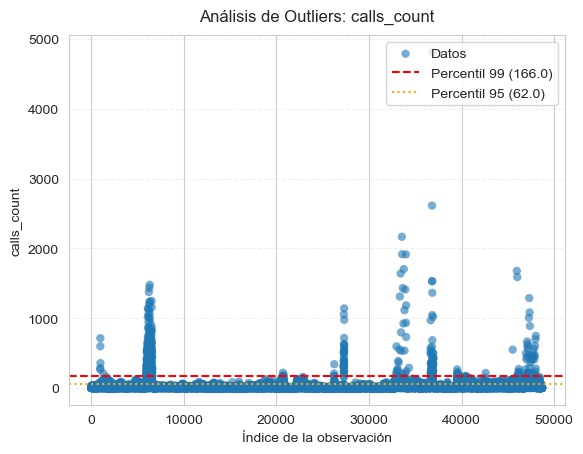

calls_count -> El 95% de los datos está abajo de: 62.00
calls_count -> El 99% de los datos está abajo de: 166.00
--------------------------------------------------


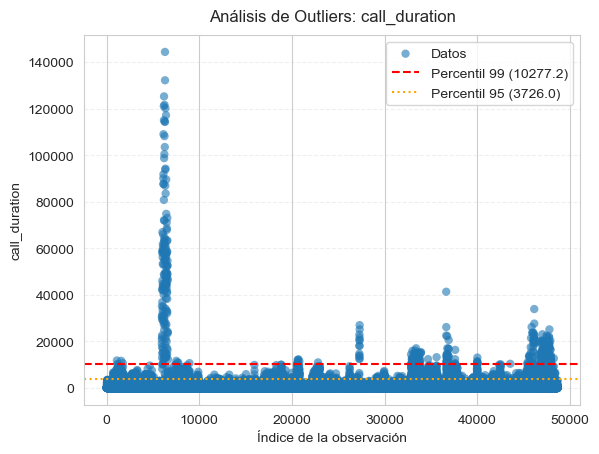

call_duration -> El 95% de los datos está abajo de: 3726.00
call_duration -> El 99% de los datos está abajo de: 10277.20
--------------------------------------------------


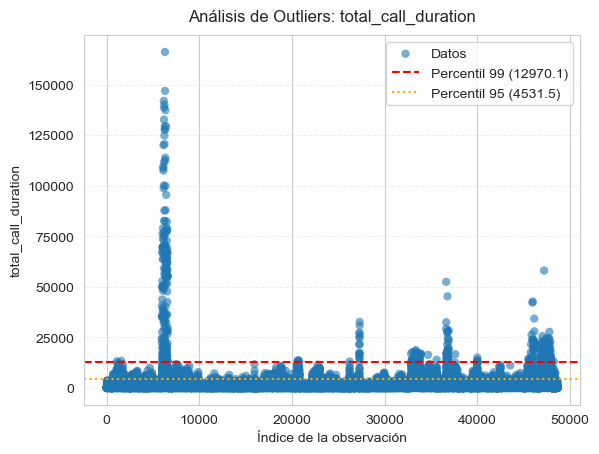

total_call_duration -> El 95% de los datos está abajo de: 4531.50
total_call_duration -> El 99% de los datos está abajo de: 12970.10
--------------------------------------------------


In [67]:
atypicals = ['calls_count', 'call_duration', 'total_call_duration']

for col in atypicals:
    plt.figure()
    
    x_values = range(0, len(calls[col]))
    plt.scatter(x_values, calls[col], alpha=0.6, edgecolor='none', label='Datos')
    
    p95 = calls[col].quantile(0.95)
    p99 = calls[col].quantile(0.99)
    
    
    plt.title(f"Análisis de Outliers: {col}", fontsize=12, pad=10)
    plt.xlabel("Índice de la observación")
    plt.ylabel(col)
    plt.axhline(y=p99, color='red', linestyle='--', linewidth=1.5, label=f'Percentil 99 ({p99:.1f})')
    plt.axhline(y=p95, color='orange', linestyle=':', linewidth=1.5, label=f'Percentil 95 ({p95:.1f})')
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.show()
    
    
    print(f"{col} -> El 95% de los datos está abajo de: {p95:.2f}")
    print(f"{col} -> El 99% de los datos está abajo de: {p99:.2f}\n" + "-"*50)

Observemos mas de cerca el 95% de nuestros datos

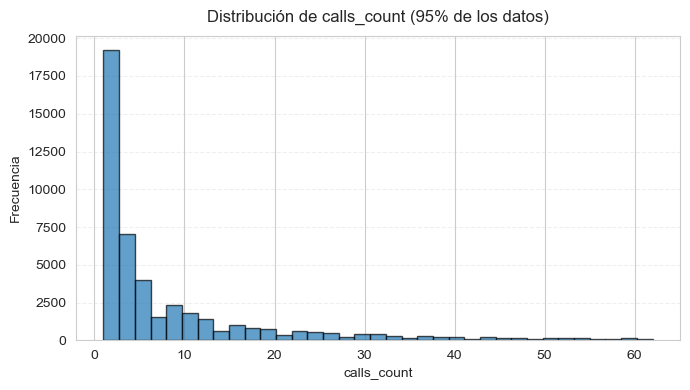

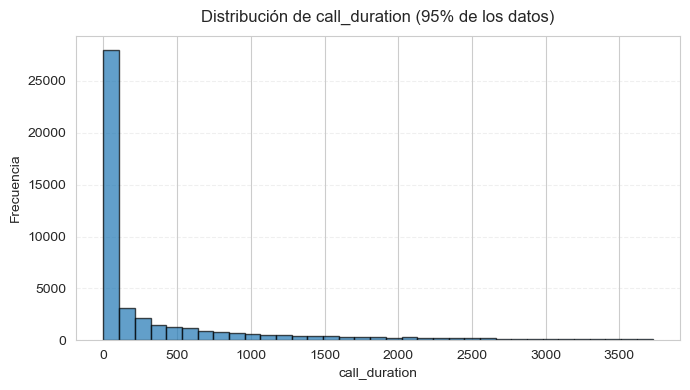

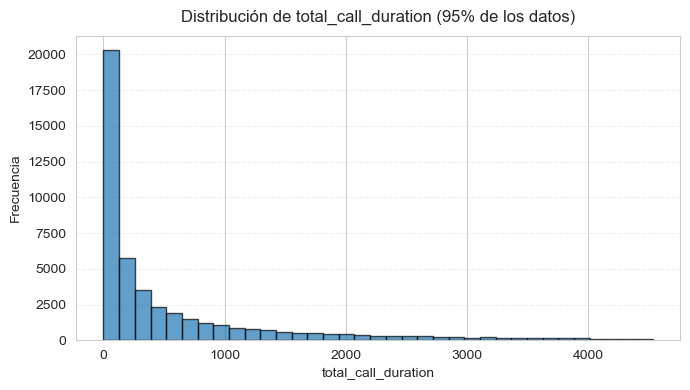

In [68]:
atypicals = ['calls_count', 'call_duration', 'total_call_duration']

for col in atypicals:
    plt.figure(figsize=(7, 4))
    
    
    limite_95 = calls[col].quantile(0.95)
    
    
    datos_tipicos = calls[calls[col] <= limite_95][col]
    
    
    datos_tipicos.hist(bins=35, edgecolor='black', alpha=0.7)
    
    
    plt.title(f"Distribución de {col} (95% de los datos)", fontsize=12, pad=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(axis='y', linestyle='--', alpha=0.3) 
    
    plt.tight_layout()
    plt.show()

Las variables de conteo y duración de llamadas no siguen una distribución normal. Al contrario, están fuertemente sesgadas a la derecha. El 95% de los datos se concentra en valores bajos, pero existe una presencia masiva de valores atípicos en el extremo derecho.

En los gráficos de dispersión, se observa que los valores atípicos no son eventos aislados o dispersos, sino que forman bloques densos (especialmente visibles en las acumulaciones verticales). Esto demuestra que corresponden a un comportamiento operativo real y sistemático, no a errores aleatorios de un solo registro. En los histogramas, fue necesario aplicar un filtro visual al percentil 95 para poder apreciar la verdadera forma y comportamiento de la masa central de los datos, la cual quedaba completamente invisibilizada por la escala de los valores máximos.

Para no sesgar el análisis ni eliminar información valiosa sobre el rendimiento del negocio, no se removerá ningún dato del dataset original. Sin embargo, dado que los promedios corrientes se ven severamente inflados por estos outliers, para la evaluación de los operadores se descarta el uso de la media aritmética y se optará por métricas robustas a valores extremos, como la mediana, además de segmentar el análisis de rendimiento entre llamadas típicas y casos atípicos.

Antes de definir nuestros criterios de evaluación para los operadores debemos conocer:

- La cantidad de operadores únicos
- La proporción de llamadas entrantes y salientes
- La proporción de llamadas perdidas
- El tiempo de espera

## ¿Cuantos operadores únicos hay?

Ahora que conocemos mejor nuestros datos debemos identificar la cantidad de operadores que hay en la empresa

In [69]:
print(f"El total de operadores activos en CallMeMaybe es de {calls["operator_id"].nunique()}")

El total de operadores activos en CallMeMaybe es de 1092


## ¿Cuál es la distribución de llamadas entrantes vs salientes?

Realizaremos un conteo de ambos tipos de llamada y obtendremos el porcentaje de los datos que representan

In [70]:
print(calls["direction"].value_counts())
print()
print(calls["direction"].value_counts(normalize=True))

direction
out    28796
in     19895
Name: count, dtype: int64

direction
out    0.591403
in     0.408597
Name: proportion, dtype: float64


Existe un 59% de llamadas salientes y 41% de llamadas entrantes

## ¿Cuál es la proporción general de llamadas perdidas?

Contamos nuestras llamadas perdidas y calculamos el porcentaje que estas representan

In [71]:
missed_calls = calls[calls["is_missed_call"] == True]
mc_proportion = len(missed_calls) / len(calls) * 100

print(f"La cantidad de llamadas perdidas es de {len(missed_calls)}")
print(f"Las llamadas perdidas representan un {mc_proportion:.2f}% de los datos")


La cantidad de llamadas perdidas es de 21258
Las llamadas perdidas representan un 43.66% de los datos


Calculamos la proporción de llamadas perdidas entrantes y salientes

In [72]:
calls.groupby("direction")["is_missed_call"].mean() * 100

direction
in     39.371701
out    46.621058
Name: is_missed_call, dtype: float64

Calculamos el porcentaje de llamadas perdidas sin operador asignado

In [73]:
missed_no_id = calls[(calls["operator_id"].isna()) & (calls["is_missed_call"] == True)].shape[0]

print(f"Hay {missed_no_id} llamadas perdidas sin operador registrado")
print(f"La proporcion de las llamadas perdidas que representan es del {missed_no_id / len(calls) * 100:.2f}%")

Hay 7149 llamadas perdidas sin operador registrado
La proporcion de las llamadas perdidas que representan es del 14.68%


Creamos un grafico para visualizar las llamadas perdidas entrantes y salientes

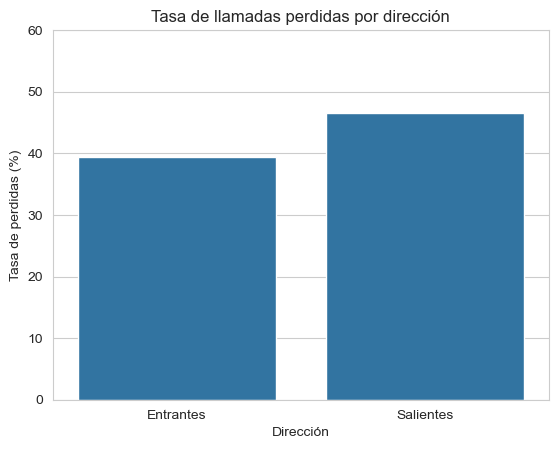

In [74]:
lost_calls = pd.DataFrame({
    'Dirección': ['Entrantes', 'Salientes'],
    'Tasa de perdidas (%)': [39.37, 46.62]
})

sns.barplot(data=lost_calls, x='Dirección', y='Tasa de perdidas (%)')
plt.title('Tasa de llamadas perdidas por dirección')
plt.ylim(0, 60)
plt.savefig('lost_calls.png', dpi=150, bbox_inches='tight')
plt.show()

La tasa de llamadas perdidas salientes (46.62%) supera a la de las entrantes (39.37%). Sin embargo, una llamada saliente perdida ocurre cuando el destinatario no contesta, lo que está fuera del control del operador. Por esta razón, el análisis de eficiencia se centrará en las llamadas entrantes perdidas, que sí son responsabilidad directa del operador.

Del 39.37% de llamadas entrantes perdidas, el 14.68% corresponde a registros sin operador asignado, posiblemente llamadas que nunca fueron enrutadas correctamente por el sistema. El 24.69% restante representa llamadas que sí tuvieron un operador responsable, lo que constituye una tasa de pérdida preocupante y justifica un análisis más profundo a nivel individual.

## Tiempo de espera

Crearemos la columna `wait_time` para medir el tiempo de espera de cada llamada

In [75]:
calls["wait_time"] = calls["total_call_duration"] - calls["call_duration"]

calls

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,wait_time
0,166377,2019-08-03,in,False,NaN,True,2,0,4,4
1,166377,2019-08-04,out,True,880022.0,True,3,0,5,5
2,166377,2019-08-04,out,True,880020.0,True,1,0,1,1
3,166377,2019-08-04,out,True,880020.0,False,1,10,18,8
4,166377,2019-08-04,out,False,880022.0,True,3,0,25,25
...,...,...,...,...,...,...,...,...,...,...
53895,168606,2019-11-08,out,False,957922.0,False,4,551,593,42
53897,168606,2019-11-09,out,True,957922.0,True,1,0,38,38
53898,168606,2019-11-10,out,True,957922.0,False,2,479,501,22
53899,168606,2019-11-14,out,True,957922.0,False,4,3130,3190,60


Revisemos nuestra nueva columna

In [76]:
calls["wait_time"].describe()

count    48691.000000
mean       291.977737
std       1135.554321
min          0.000000
25%         17.000000
50%         56.000000
75%        202.000000
max      46474.000000
Name: wait_time, dtype: float64

El tiempo de espera se calcula como la diferencia entre total_call_duration y call_duration. No existen valores negativos, lo que confirma la consistencia de los datos. La mediana de espera es de 56 segundos, aunque la media se ve inflada a 291 segundos por valores atípicos, por lo que se usará la mediana como métrica representativa.

# Análisis de datos: Identificación de operadores ineficaces

Comencemos calculando las métricas con las que se evaluara a los operadores

In [77]:
operator_stats = calls.groupby("operator_id").agg(
    missed_call_rate=("is_missed_call", "mean"),
    avg_wait_time=("wait_time", "median")
)

# Conteo de llamadas salientes por operador
outgoing_calls = calls[calls["direction"] == "out"].groupby("operator_id")["calls_count"].sum()

# Unimos
operator_stats = operator_stats.join(outgoing_calls.rename("outgoing_calls"))

In [78]:
operator_stats.head()

,missed_call_rate,avg_wait_time,outgoing_calls
operator_id,,,
879896.0,0.401709,27.0,872.0
879898.0,0.393805,393.0,7209.0
880020.0,0.300000,8.0,38.0
880022.0,0.414286,13.0,189.0
880026.0,0.478022,112.0,2208.0


Aplicamos `.describe()` para definir los umbrales de nuestras métricas

In [79]:
operator_stats.describe()

,missed_call_rate,avg_wait_time,outgoing_calls
count,1092.000000,1092.000000,882.000000
mean,0.315991,181.667125,689.710884
std,0.230158,420.965654,3122.956565
min,0.000000,0.000000,1.000000
25%,0.134685,16.500000,11.000000
50%,0.333333,32.000000,90.000000
75%,0.473684,104.625000,597.250000
max,1.000000,4525.000000,58977.000000


Para identificar operadores ineficaces se utilizarán los siguientes umbrales basados en percentiles:

- Para `missed_call_rate` y `avg_wait_time`, métricas donde un valor alto indica mal desempeño, se utilizará el percentil 75 como umbral. Los operadores que superen este valor se considerarán candidatos ineficaces.

- Para `outgoing_calls`, métrica donde un valor bajo indica mal desempeño, se utilizará el percentil 25 como umbral. Los operadores que estén por debajo de este valor se considerarán candidatos ineficaces.

In [80]:
threshold_missed = operator_stats["missed_call_rate"].quantile(0.75)
threshold_wait = operator_stats["avg_wait_time"].quantile(0.75)
threshold_outgoing = operator_stats["outgoing_calls"].quantile(0.25)

print(f"Umbral missed_call_rate: {threshold_missed:.3f}")
print(f"Umbral avg_wait_time: {threshold_wait:.1f}")
print(f"Umbral outgoing_calls: {threshold_outgoing:.1f}")

Umbral missed_call_rate: 0.474
Umbral avg_wait_time: 104.6
Umbral outgoing_calls: 11.0


Crearemos tres columnas booleanas que nos ayudaran a identificar si un operador supera los umbrales o no

In [81]:
operator_stats["high_missed_calls"] = operator_stats["missed_call_rate"] > threshold_missed
operator_stats["high_wait_time"] = operator_stats["avg_wait_time"] > threshold_wait
operator_stats["low_outgoing_calls"] = operator_stats["outgoing_calls"] < threshold_outgoing

Dado que la eficiencia de un operador se evalúa con base en tres métricas, se identificará como ineficaz a todo operador que supere el umbral de ineficiencia en al menos dos de los tres criterios establecidos.

In [82]:
operator_stats["inefficient"] = (
    operator_stats["high_missed_calls"].astype(int) +
    operator_stats["high_wait_time"].astype(int) +
    operator_stats["low_outgoing_calls"].astype(int)
) >= 2

inefficient_op = operator_stats[operator_stats["inefficient"] == True]

inefficient_op

,missed_call_rate,avg_wait_time,outgoing_calls,high_missed_calls,high_wait_time,low_outgoing_calls,inefficient
operator_id,,,,,,,
880026.0,0.478022,112.0,2208.0,True,True,False,True
883018.0,1.000000,15.0,2.0,True,False,True,True
884406.0,0.500000,35.5,3.0,True,False,True,True
884478.0,0.482353,391.0,2270.0,True,True,False,True
885682.0,1.000000,18.0,3.0,True,False,True,True
...,...,...,...,...,...,...,...
970484.0,0.666667,16.0,7.0,True,False,True,True
970486.0,0.500000,10.0,6.0,True,False,True,True
972408.0,0.500000,22.5,6.0,True,False,True,True


Calculamos la proporción de operadores ineficaces

In [83]:
print(f"Hay {operator_stats["inefficient"].sum()} operadores ineficaces")
print(f"La proporción de operadores ineficaces es del {operator_stats["inefficient"].sum() / len(operator_stats) * 100:.2f}%")

Hay 221 operadores ineficaces
La proporción de operadores ineficaces es del 20.24%


Llamamos a `.head()` para verificar nuestra nueva tabla

In [84]:
operator_stats[operator_stats["inefficient"] == True].head(10)


,missed_call_rate,avg_wait_time,outgoing_calls,high_missed_calls,high_wait_time,low_outgoing_calls,inefficient
operator_id,,,,,,,
880026.0,0.478022,112.0,2208.0,True,True,False,True
883018.0,1.000000,15.0,2.0,True,False,True,True
884406.0,0.500000,35.5,3.0,True,False,True,True
884478.0,0.482353,391.0,2270.0,True,True,False,True
885682.0,1.000000,18.0,3.0,True,False,True,True
887280.0,0.666667,0.5,8.0,True,False,True,True
887992.0,0.500000,108.0,47.0,True,True,False,True
890410.0,0.493151,118.0,1215.0,True,True,False,True
890416.0,0.482014,126.0,1271.0,True,True,False,True


Se identificaron 221 operadores ineficaces (20.2% del total). Si bien algunos de estos operadores muestran alto volumen de llamadas salientes pero fallan en las otras dos métricas, se mantiene el criterio unificado de ineficiencia. Para los operadores que superan los umbrales por un margen reducido, se recomienda intervención mediante capacitación. Para aquellos con métricas consistentemente malas en los tres criterios, se sugiere una revisión más profunda de su perfil operativo.

# Prueba de hipótesis

## Hipótesis 1

*Los operadores ineficaces tienen tiempos de espera significativamente mayores que los eficaces*

**Hipótesis nula (H₀)**: No existe diferencia significativa en el tiempo de espera entre operadores eficaces e ineficaces

**Hipótesis alternativa(H₁)**: Los operadores ineficaces tienen tiempos de espera significativamente mayores

**Valor alfa (α)** = 0.05

Si el *p-value* ≤ *α*, se rechaza la hipótesis nula, de lo contrario, no se rechaza

Debido a que la distribución de los datos no es normal, se utilizara una prueba Mann-Whitney para comprobar nuestra hipótesis

In [85]:
efficient = operator_stats[operator_stats["inefficient"] == False]["avg_wait_time"]
inefficient = operator_stats[operator_stats["inefficient"] == True]["avg_wait_time"]

stat, p_value = st.mannwhitneyu(efficient, inefficient, alternative="less")

alpha = 0.05

print(f"P-value: {p_value}")

if p_value < alpha:
    print("Se rechaza la hipotesis nula")
else:
    print("No se rechaza la hipotesis nula")

P-value: 7.340489082548126e-21
Se rechaza la hipotesis nula


La prueba Mann-Whitney arrojó un p-value de 7.34e-21, muy por debajo del nivel de significancia de 0.05, lo que confirma que existe evidencia estadística suficiente para rechazar la hipótesis nula. Los operadores ineficaces tienen tiempos de espera significativamente mayores que los eficaces.

Esto sugiere que el tiempo de espera es una de las principales problemáticas de los operadores ineficaces. Se recomienda implementar alertas automáticas cuando el tiempo de espera supere el umbral establecido (104.6 segundos) y diseñar capacitaciones específicas en gestión de tiempos de atención para los operadores identificados.

## Hipótesis 2

*Los clientes con ciertos planes tarifarios tienen una mayor proporción de operadores ineficaces.*

**Hipótesis nula (H₀)**: No existe diferencia significativa en la proporción de operadores ineficaces entre clientes con diferentes planes tarifarios

**Hipótesis alternativa(H₁)**: La proporción de operadores ineficaces varía significativamente según el plan tarifario del cliente

**Valor alfa (α)** = 0.016 (Como se realizaran tres pruebas se divide el valor alfa (0.05) entre tres)

Si el *p-value* ≤ *α*, se rechaza la hipótesis nula, de lo contrario, no se rechaza

Como se compararan proporciones entre grupos se utilizara z-test para realizar nuestra prueba estadística

Antes de realizar la prueba necesitamos unir la tabla `operator_stats` con  `clients`, para esto usaremos la tabla `calls` como puente

Primero creamos una matriz que contenga pares únicos operador-cliente

In [86]:
operator_client = calls[["operator_id", "user_id"]].drop_duplicates()

Unimos el resultado con `clients`

In [87]:
operator_tariff = operator_client.merge(clients[["user_id", "tariff_plan"]], on="user_id", how="left")

Y ahora con `operator_stats`

In [88]:
operator_tariff = operator_tariff.merge(operator_stats[["inefficient"]], on="operator_id", how="left")

In [89]:
operator_tariff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   operator_id  1092 non-null   float64
 1   user_id      1397 non-null   int64  
 2   tariff_plan  1397 non-null   object 
 3   inefficient  1092 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 43.8+ KB


Eliminamos valores nulos

In [90]:
operator_tariff = operator_tariff.dropna(subset=["inefficient"])

Calculamos la proporción de operadores ineficaces por tarifa

In [91]:
print(operator_tariff.groupby("tariff_plan")["inefficient"].mean() * 100)

tariff_plan
A    32.258065
B    17.468354
C    13.436693
Name: inefficient, dtype: object


Para cada plan tarifario se calculó el número total de operadores y la cantidad catalogada como ineficaz, con el fin de comparar las proporciones de ineficiencia entre tarifas mediante una prueba Z.

In [92]:
tariff_groups = operator_tariff.groupby("tariff_plan")["inefficient"].agg(["sum", "count"])
print(tariff_groups)

             sum  count
tariff_plan            
A            100    310
B             69    395
C             52    387


Procedemos con el z-test

In [93]:
# A vs B
stat_ab, p_ab = proportions_ztest(
    [tariff_groups.loc["A", "sum"], tariff_groups.loc["B", "sum"]],
    [tariff_groups.loc["A", "count"], tariff_groups.loc["B", "count"]]
)

# A vs C
stat_ac, p_ac = proportions_ztest(
    [tariff_groups.loc["A", "sum"], tariff_groups.loc["C", "sum"]],
    [tariff_groups.loc["A", "count"], tariff_groups.loc["C", "count"]]
)

# B vs C
stat_bc, p_bc = proportions_ztest(
    [tariff_groups.loc["B", "sum"], tariff_groups.loc["C", "sum"]],
    [tariff_groups.loc["B", "count"], tariff_groups.loc["C", "count"]]
)

alpha = 0.05 / 3  # Bonferroni

print(f"A vs B: p-value = {p_ab} {'Se rechaza la hipótesis nula' if p_ab < alpha else 'No se rechaza la hipótesis nula'}")
print(f"A vs C: p-value = {p_ac} {'Se rechaza la hipótesis nula' if p_ac < alpha else 'No se rechaza la hipótesis nula'}")
print(f"B vs C: p-value = {p_bc} {'Se rechaza la hipótesis nula' if p_bc < alpha else 'No se rechaza la hipótesis nula'}")

A vs B: p-value = 4.978179438182181e-06 Se rechaza la hipótesis nula
A vs C: p-value = 2.2346287014161747e-09 Se rechaza la hipótesis nula
B vs C: p-value = 0.11907967102409295 No se rechaza la hipótesis nula


Las pruebas Z confirman que la tarifa A presenta una proporción de operadores ineficaces (32.3%) significativamente mayor que las tarifas B (17.5%) y C (13.4%), con p-values de 4.98e-06 y 2.23e-09 respectivamente. No existe diferencia significativa entre las tarifas B y C (p = 0.119).

Esto sugiere que los clientes con tarifa A reciben un servicio de menor calidad en términos de eficiencia operativa. Una hipótesis plausible es que la tarifa A sea la más económica y que los clientes de este plan reciban operadores con menor experiencia o en periodo de entrenamiento. Se recomienda investigar la composición de operadores asignados a cada tarifa y revisar la política de asignación.

# Conclusión

El análisis identificó 221 operadores ineficaces (20.2% del total de 1,092), definidos como aquellos que superan los umbrales de ineficiencia en al menos dos de los tres criterios establecidos: tasa de llamadas perdidas entrantes superior al 47.4%, tiempo de espera mediano superior a 104.6 segundos, y volumen de llamadas salientes inferior a 11.
El análisis estadístico confirmó que los operadores ineficaces tienen tiempos de espera significativamente mayores que los eficaces (p = 7.34e-21), lo que indica que la gestión del tiempo de atención es una de sus principales debilidades.

Adicionalmente, se encontró que la proporción de operadores ineficaces varía significativamente según el plan tarifario del cliente. La tarifa A concentra el 32.3% de operadores ineficaces, casi el doble que las tarifas B (17.5%) y C (13.4%), lo que sugiere una posible asignación inequitativa de operadores según el plan contratado.

# Recomendaciones

1. Capacitación dirigida: Diseñar un programa de capacitación específico para los 221 operadores ineficaces, enfocado en reducir tiempos de espera y mejorar la tasa de atención de llamadas entrantes.

2. Sistema de alertas: Implementar alertas automáticas cuando un operador supere el umbral de tiempo de espera (104.6 segundos) o tasa de llamadas perdidas (47.4%), permitiendo intervención en tiempo real.

3. Revisión de asignación por tarifa: Investigar la política de asignación de operadores a clientes con tarifa A y garantizar que todos los planes reciban operadores con niveles de experiencia equivalentes.

4. Monitoreo continuo: Establecer un proceso de revisión periódica de las métricas de eficiencia por operador, utilizando los umbrales definidos en este análisis como referencia base."

# Fuentes

1. [Pandas Documentation](https://pandas.pydata.org/docs/) — Consultas sobre métodos de agrupación, filtrado y manipulación de DataFrames.

2. [SciPy Documentation - Mann-Whitney U test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html) — Para entender los parámetros y la interpretación del estadístico U en distribuciones no normales.

3. [Statsmodels Documentation - proportions_ztest](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html) — Para la implementación de la prueba Z de proporciones en la comparación de tarifas.

4. [Towards Data Science - Outlier Detection Methods](https://towardsdatascience.com/ways-to-detect-and-remove-the-outliers-404d16608dba) — Para justificar el uso de percentiles como criterio de detección de valores atípicos.

5. [Statistics How To - Bonferroni Correction](https://www.statisticshowto.com/bonferroni-correction/) — Para la aplicación correcta de la corrección de Bonferroni en pruebas múltiples.